#Time Series Forecasting (Prophet)

In [ ]:
import matplotlib

In [3]:
import pandas as pd
from prophet import Prophet

In [4]:
df = pd.read_csv('/content/MonthlyProductDemand.csv', encoding='utf-8')
df.head(10)

,ProductKey,ProductName,Year,MonthName,NumTransactions,TotalDemandQty,AvgUnitPrice,AvgReorderPoint,SafetyStockLevel,AvgLeadTime
0,19088,LL Mountain Pedal,2012,January,3,512.0,31.4895,375,500,18
1,18710,Hex Nut 23,2012,March,3,1901.0,47.5440,750,1000,15
2,18655,ML Crankarm,2012,May,6,878.0,34.8390,375,500,18
3,18693,Thin-Jam Hex Nut 6,2012,May,6,2058.0,41.3017,750,1000,18
4,19081,LL Mountain Tire,2012,August,4,1218.0,32.5080,375,500,19
5,19085,ML Road Tire,2013,May,4,1148.0,39.5010,375,500,19
6,18810,Metal Sheet 3,2014,May,3,1681.0,9.6915,750,1000,15
7,18674,Flat Washer 4,2014,June,18,5616.0,40.1380,750,1000,17
8,18749,Thin-Jam Lock Nut 9,2014,July,12,6528.0,47.6411,750,1000,17
9,19090,HL Mountain Pedal,2014,August,3,503.0,62.9895,375,500,18


In [7]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['Month'] = df['MonthName'].map(month_map)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values(['ProductName', 'Date'])

In [8]:
df[['ProductKey', 'ProductName', 'Year', 'Month', 'NumTransactions', 'TotalDemandQty']]

,ProductKey,ProductName,Year,Month,NumTransactions,TotalDemandQty
2025,18865,AWC Logo Cap,2014,5,1,288.0
1086,18649,Adjustable Race,2011,4,3,1085.0
1376,18649,Adjustable Race,2012,2,3,1085.0
1741,18649,Adjustable Race,2012,5,3,1085.0
2938,18649,Adjustable Race,2012,9,3,1085.0
...,...,...,...,...,...,...
2570,19021,"Women's Mountain Shorts, M",2014,4,1,252.0
730,19020,"Women's Mountain Shorts, S",2014,4,1,216.0
579,19007,"Women's Tights, L",2014,3,1,36.0
1404,19006,"Women's Tights, M",2014,3,1,0.0


In [13]:
df = pd.read_csv('/content/MonthlyProductDemand.csv', encoding='utf-8')
# Convert Month name → month number (1–12)

forecast_results = []

# ---Forecast loop per product ---
for (product_key, product_name), group in df.groupby(['ProductKey', 'ProductName']):
    ts = group[['Date', 'TotalDemandQty']].rename(columns={'Date': 'ds', 'TotalDemandQty': 'y'})

    if len(ts) < 4:
        continue  # skip products with too few data points

    # Prophet model
    model = Prophet(yearly_seasonality=True, seasonality_mode='additive')
    model.fit(ts)

    # Forecast next 6 months
    future = model.make_future_dataframe(periods=6, freq='M')
    forecast = model.predict(future)

    # Keep only new forecast months
    future_forecast = forecast[forecast['ds'] > ts['ds'].max()]
    future_forecast = future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

    # Add product metadata
    future_forecast['ProductKey'] = product_key
    future_forecast['ProductName'] = product_name

    # ---Clip any negative predictions ---
    future_forecast[['yhat', 'yhat_lower', 'yhat_upper']] = \
        future_forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)

    forecast_results.append(future_forecast)
# ---Combine all forecasts ---
forecast_df = pd.concat(forecast_results)

# Rename columns for clarity
forecast_df.rename(columns={
    'ds':'ForecastMonth',
    'yhat':'PredictedDemandQty',
    'yhat_lower':'LowerBound',
    'yhat_upper':'UpperBound'
}, inplace=True)


print(forecast_df.head())


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk4i_u4kp/4n025i10.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk4i_u4kp/mlry9nh8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=98147', 'data', 'file=/tmp/tmpk4i_u4kp/4n025i10.json', 'init=/tmp/tmpk4i_u4kp/mlry9nh8.json', 'output', 'file=/tmp/tmpk4i_u4kp/prophet_modelt4yqrpva/prophet_model-20251026164038.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
16:40:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:40:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:

✅ Forecasting complete!
   ForecastMonth  PredictedDemandQty    LowerBound    UpperBound  ProductKey  \
18    2014-07-31         4458.647925   4457.319693   4461.003578       18649   
19    2014-08-31         5987.649686   5981.445002   5996.204839       18649   
20    2014-09-30            0.000000      0.000000      0.000000       18649   
21    2014-10-31        14404.551567  14380.325023  14433.987946       18649   
22    2014-11-30            0.000000      0.000000      0.000000       18649   

        ProductName  
18  Adjustable Race  
19  Adjustable Race  
20  Adjustable Race  
21  Adjustable Race  
22  Adjustable Race  


In [14]:
forecast_df

,ForecastMonth,PredictedDemandQty,LowerBound,UpperBound,ProductKey,ProductName
18,2014-07-31,4458.647925,4457.319693,4461.003578,18649,Adjustable Race
19,2014-08-31,5987.649686,5981.445002,5996.204839,18649,Adjustable Race
20,2014-09-30,0.000000,0.000000,0.000000,18649,Adjustable Race
21,2014-10-31,14404.551567,14380.325023,14433.987946,18649,Adjustable Race
22,2014-11-30,0.000000,0.000000,0.000000,18649,Adjustable Race
...,...,...,...,...,...,...
18,2014-08-31,0.000000,0.000000,0.000000,19105,Chain
19,2014-09-30,682.618629,461.513670,907.889533,19105,Chain
20,2014-10-31,2369.395123,2157.318548,2568.229779,19105,Chain
21,2014-11-30,5373.950209,5163.192062,5593.596281,19105,Chain


In [15]:
unique_products = forecast_df['ProductName'].unique()
print(len(unique_products))

211


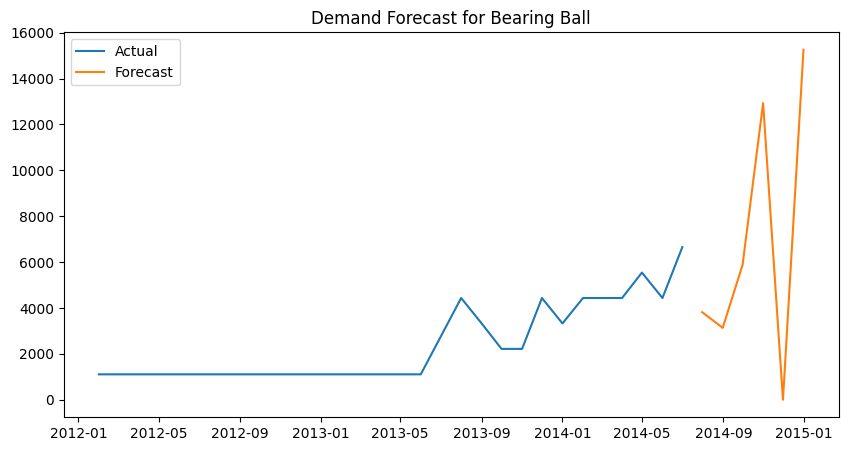

In [16]:
import matplotlib.pyplot as plt

sample_product = 'Bearing Ball'
subset = df[df['ProductName'] == sample_product]
future_part = forecast_df[forecast_df['ProductName'] == sample_product]

plt.figure(figsize=(10,5))
plt.plot(subset['Date'], subset['TotalDemandQty'], label='Actual')
plt.plot(future_part['ForecastMonth'], future_part['PredictedDemandQty'], label='Forecast')
plt.fill_between(future_part['ForecastMonth'],
                 future_part['LowerBound'], future_part['UpperBound'], alpha=0.3)
plt.title(f'Demand Forecast for {sample_product}')
plt.legend()
plt.show()

In [17]:
forecast_df.to_csv('Forecast_ProductDemand.csv', index=False)
from google.colab import files
files.download('Forecast_ProductDemand.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>